# Superstore Sales Analysis

This notebook provides an exploratory data analysis (EDA) and visualization of the Superstore dataset.

In [6]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [23]:
# Load and Clean Data
df = pd.read_csv('../data/raw/Sample - Superstore.csv', encoding='latin1')
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]

In [24]:
# Feature Engineering
df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.to_period('M').astype(str)
df['shipping_days'] = (pd.to_datetime(df['ship_date']) - df['order_date']).dt.days

In [25]:
# Set Visualization Theme
sns.set_theme(style='whitegrid', palette='muted')

Text(0.5, 1.01, 'Superstore Sales Analysis')

Text(0.5, 1.01, 'Superstore Sales Analysis')

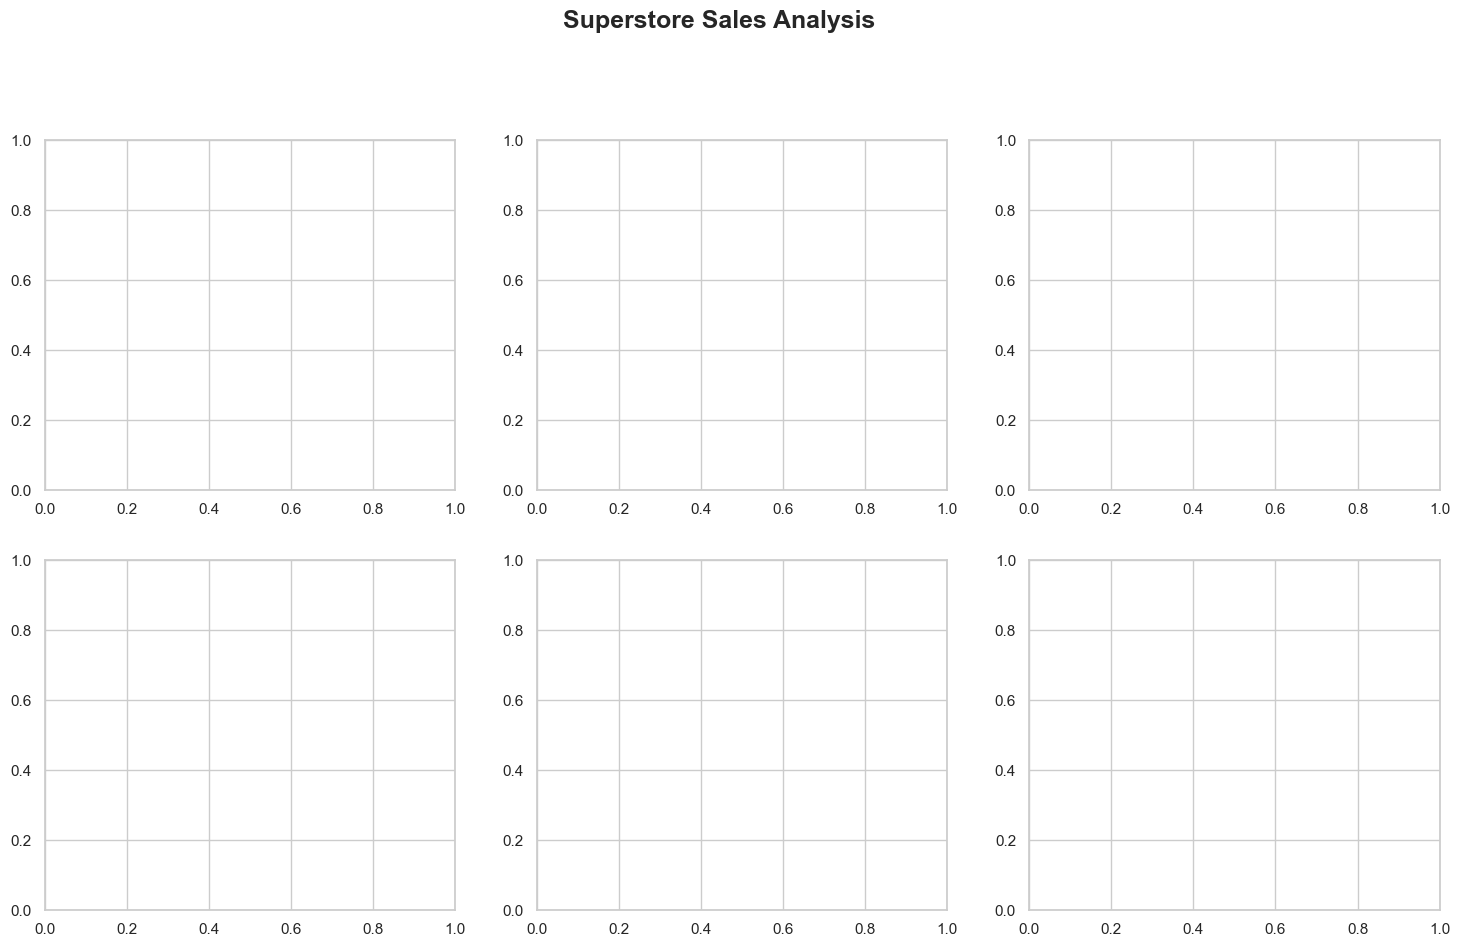

In [10]:
# Create Subplots for Analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Superstore Sales Analysis', fontsize=18, fontweight='bold', y=1.01)

In [11]:
# Monthly Sales and Profit Trend
monthly = df.groupby('month')[['sales','profit']].sum().reset_index()
axes[0,0].plot(monthly['month'], monthly['sales'], marker='o', color='#534AB7', label='Sales')
axes[0,0].plot(monthly['month'], monthly['profit'], marker='s', color='#1D9E75', label='Profit')
axes[0,0].set_title('Monthly sales & profit trend')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

In [12]:
# Sales by Category
cat = df.groupby('category')['sales'].sum().sort_values()
axes[0,1].barh(cat.index, cat.values, color=['#D85A30','#534AB7','#1D9E75'])
axes[0,1].set_title('Sales by category')
axes[0,1].set_xlabel('Sales ($)')

Text(0.5, 424.44444444444446, 'Sales ($)')

In [13]:
# Profit Margin by Sub-Category
sub = df.groupby('sub_category').apply(lambda x: 100*x['profit'].sum()/x['sales'].sum()).sort_values()
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in sub.values]
axes[0,2].barh(sub.index, sub.values, color=colors)
axes[0,2].axvline(0, color='black', linewidth=0.8)
axes[0,2].set_title('Profit margin % by sub-category')
axes[0,2].set_xlabel('Profit margin %')

Text(0.5, 424.44444444444446, 'Profit margin %')

In [14]:
# Discount vs Profit Scatter Plot
axes[1,0].scatter(df['discount'], df['profit'], alpha=0.3, color='#534AB7', s=10)
axes[1,0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[1,0].set_title('Discount vs profit (each order)')
axes[1,0].set_xlabel('Discount rate')
axes[1,0].set_ylabel('Profit ($)')

Text(4.444444444444459, 0.5, 'Profit ($)')

In [15]:
# Sales by Region
region = df.groupby('region')['sales'].sum().sort_values(ascending=False)
axes[1,1].bar(region.index, region.values, color='#378ADD')
axes[1,1].set_title('Sales by region')
axes[1,1].set_ylabel('Sales ($)')

Text(496.79738562091507, 0.5, 'Sales ($)')

In [16]:
# Shipping Mode Distribution
ship = df.groupby('ship_mode')['order_id'].count().sort_values()
axes[1,2].barh(ship.index, ship.values, color='#EF9F27')
axes[1,2].set_title('Orders by shipping mode')
axes[1,2].set_xlabel('Number of orders')

Text(0.5, 4.444444444444445, 'Number of orders')

In [17]:
# Display and Save Plots
plt.tight_layout()
plt.savefig('../superstore_eda.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [18]:
# Print Key Insights
print('\n=== KEY INSIGHTS ===')
print(f"Total Revenue: ${df['sales'].sum():,.0f}")
print(f"Total Profit: ${df['profit'].sum():,.0f}")
print(f"Overall Margin: {100*df['profit'].sum()/df['sales'].sum():.1f}%")
print(f"\nMost profitable category: {df.groupby('category')['profit'].sum().idxmax()}")
print(f"Least profitable sub-category: {df.groupby('sub_category')['profit'].sum().idxmin()}")
print(f"\nHighest sales region: {df.groupby('region')['sales'].sum().idxmax()}")
print(f"Discount correlation with profit: {df['discount'].corr(df['profit']):.2f}")
print(f"\nAvg shipping days (Standard Class): {df[df['ship_mode']=='Standard Class']['shipping_days'].mean():.1f} days")


=== KEY INSIGHTS ===
Total Revenue: $2,297,201
Total Profit: $286,397
Overall Margin: 12.5%

Most profitable category: Technology
Least profitable sub-category: Tables

Highest sales region: West
Discount correlation with profit: -0.22

Avg shipping days (Standard Class): 5.0 days
